# Social Media Donation Conversion Classifier

This notebook builds a **strategy-focused social media pipeline** for the INTEX IS 455 requirement. The goal is to help staff make better decisions **before publishing a post** by predicting whether a planned post is likely to become a **high donation-referral post**.

This notebook is intentionally structured to match the required assignment sections:

1. Problem Framing  
2. Data Acquisition, Preparation & Exploration  
3. Modeling & Feature Selection  
4. Evaluation & Interpretation  
5. Causal and Relationship Analysis  
6. Deployment Notes

The implementation follows the textbook emphasis on:
- prediction vs. explanation
- reproducible data preparation pipelines
- dummy coding / one-hot encoding where appropriate
- thoughtful feature selection
- proper validation
- deployment as part of the pipeline, not an afterthought

## 1. Problem Framing

### Business question
Which planned social media posts are most likely to become **high donation-referral posts**?

### Who cares about this?
This pipeline is most useful for:
- communications and outreach staff planning content
- fundraising staff who want social media to support donation growth
- leadership who want evidence about which content strategy appears to work best

### Why this matters
The case says social media is the organization’s primary channel for reaching potential donors, but the founders are unsure what to post, on which platforms, how often, and at what times. A strategy-focused classifier can help move them from ad hoc posting to a more deliberate content plan.

### Predictive vs. explanatory choice
This notebook is **primarily predictive** because the organization needs a usable pre-publication recommendation tool. The notebook also includes a relationship analysis section so the team can interpret which planning choices seem associated with stronger donation-referral performance.

### Target used in this notebook
This notebook defines:
- `high_donation_referral = 1` if a post lands in the top quartile of donation referrals
- `high_donation_referral = 0` otherwise

### Important design choice
This is a **before publishing** strategy model. The model uses only features known before a post goes live, such as platform, post type, posting hour, day of week, caption length, hashtag count, CTA type, boost status, budget, campaign, and media format. It does **not** use post-publication outcomes like reach, clicks, impressions, or engagement rate.

In [10]:
# Imports, configuration, and helper functions

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.feature_selection import SelectFromModel
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate, RandomizedSearchCV
    from sklearn.metrics import (
        roc_auc_score,
        average_precision_score,
        f1_score,
        precision_score,
        recall_score,
        confusion_matrix,
        classification_report,
        RocCurveDisplay,
        PrecisionRecallDisplay,
    )
    from sklearn.inspection import permutation_importance
except ImportError as exc:
    raise ImportError(
        "Missing required Python packages. Install them with: python -m pip install scikit-learn pandas matplotlib"
    ) from exc

warnings.filterwarnings("ignore")

def resolve_data_dir(candidates):
    for candidate in candidates:
        if candidate.exists() and any(candidate.glob("*.csv")):
            return candidate
    for candidate in candidates:
        if candidate.exists():
            for sub in candidate.iterdir():
                if sub.is_dir() and any(sub.glob("*.csv")):
                    return sub
    raise FileNotFoundError(
        "Could not find a data folder containing CSV files. Checked: "
        + ", ".join(str(p.resolve()) for p in candidates)
    )

SEED = 27
ANALYSIS_CUTOFF = pd.Timestamp("2026-04-06")

OUTPUT_DIR = Path("./generated_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR_CANDIDATES = [
    Path("./lighthouse_csv_v7/lighthouse_csv_v7"),
    Path("./lighthouse_csv_v7"),
    Path("../lighthouse_csv_v7/lighthouse_csv_v7"),
    Path("../lighthouse_csv_v7"),
]

def resolve_data_dir(candidates):
    for candidate in candidates:
        if candidate.exists() and any(candidate.glob("*.csv")):
            return candidate
    for candidate in candidates:
        if candidate.exists():
            for sub in candidate.iterdir():
                if sub.is_dir() and any(sub.glob("*.csv")):
                    return sub
    raise FileNotFoundError(
        "Could not find a data folder containing CSV files. Checked: "
        + ", ".join(str(p.resolve()) for p in candidates)
    )

DATA_DIR = resolve_data_dir(DATA_DIR_CANDIDATES)

REQUIRED_FILES = {
    "social_media_posts": DATA_DIR / "social_media_posts.csv",
    "donations": DATA_DIR / "donations.csv",
}

print("Working directory:", Path.cwd())
print("Resolved data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())
print("CSV files found:")
for p in sorted(DATA_DIR.glob("*.csv")):
    print("-", p.name)

Working directory: c:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines
Resolved data directory: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines\lighthouse_csv_v7\lighthouse_csv_v7
Output directory: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines\generated_outputs
CSV files found:
- donation_allocations.csv
- donations.csv
- education_records.csv
- health_wellbeing_records.csv
- home_visitations.csv
- in_kind_donation_items.csv
- incident_reports.csv
- intervention_plans.csv
- partner_assignments.csv
- partners.csv
- process_recordings.csv
- public_impact_snapshots.csv
- residents.csv
- safehouse_monthly_metrics.csv
- safehouses.csv
- social_media_posts.csv
- supporters.csv


## 2. Data Acquisition, Preparation & Exploration

This section loads the social media data and prepares a reproducible modeling dataset.

### Tables used
- `social_media_posts`
- `donations` (used only to validate attribution logic, not as a feature source for the pre-publication model)

### Why these tables?
The social media table contains the planning and publishing variables needed for a strategy model. The donations table provides a useful attribution check because some donations reference posts through `referral_post_id`.

In [11]:
# Load tables and parse dates

social_media_posts = load_csv_safe(
    REQUIRED_FILES["social_media_posts"],
    parse_dates=["created_at"],
)

donations = load_csv_safe(
    REQUIRED_FILES["donations"],
    parse_dates=["donation_date"],
)

validate_required_columns(
    social_media_posts,
    "social_media_posts",
    [
        "post_id", "created_at", "platform", "post_type", "post_hour",
        "day_of_week", "caption_length", "num_hashtags", "call_to_action_type",
        "boost_budget_php", "donation_referrals",
    ],
)

validate_required_columns(
    donations,
    "donations",
    ["donation_id", "donation_date", "referral_post_id", "estimated_value"],
)

print("social_media_posts:", social_media_posts.shape)
print("donations:", donations.shape)

social_media_posts: (812, 39)
donations: (420, 13)


In [12]:
# Filter future-dated rows

social_media_posts = social_media_posts[social_media_posts["created_at"] <= ANALYSIS_CUTOFF].copy()
donations = donations[donations["donation_date"] <= ANALYSIS_CUTOFF].copy()

print("Rows after cutoff filtering")
print("social_media_posts:", social_media_posts.shape)
print("donations:", donations.shape)

Rows after cutoff filtering
social_media_posts: (812, 39)
donations: (420, 13)


In [13]:
# Attribution cross-check

attributed_donations = donations[donations["referral_post_id"].notna()].copy()
attributed_donations["referral_post_id"] = pd.to_numeric(attributed_donations["referral_post_id"], errors="coerce")

attribution_summary = (
    attributed_donations.groupby("referral_post_id", dropna=True)
    .agg(
        referred_donation_count=("donation_id", "count"),
        referred_estimated_value=("estimated_value", "sum"),
    )
    .reset_index()
    .rename(columns={"referral_post_id": "post_id"})
)

social = social_media_posts.merge(attribution_summary, on="post_id", how="left")
social["referred_donation_count"] = social["referred_donation_count"].fillna(0)
social["referred_estimated_value"] = social["referred_estimated_value"].fillna(0)

social[["post_id", "donation_referrals", "referred_donation_count", "referred_estimated_value"]].head()

,post_id,donation_referrals,referred_donation_count,referred_estimated_value
0,318,10,0.0,0.0
1,529,2,0.0,0.0
2,86,0,0.0,0.0
3,380,0,0.0,0.0
4,425,2,0.0,0.0


Posts: 812
Platforms: 7
Post types: 6
Average donation referrals per post: 12.8
Median donation referrals per post: 2.0


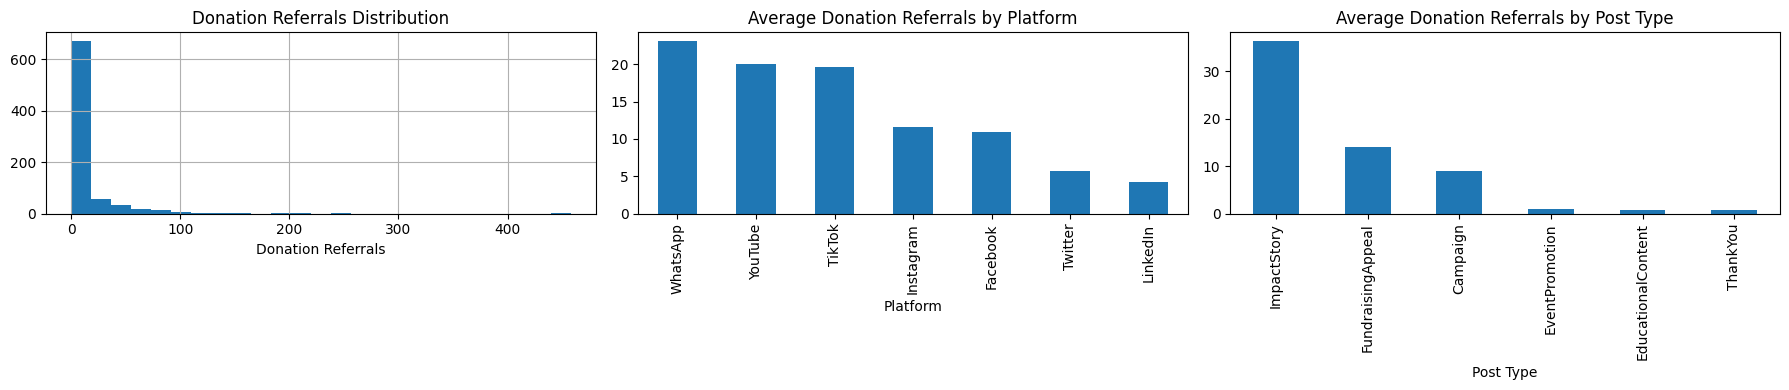

,post_hour,donation_referrals
0,0,0.944444
1,1,1.592593
2,2,0.066667
3,3,1.100000
4,4,0.483871


In [14]:
# Exploratory visuals and summary statistics

print("Posts:", len(social))
print("Platforms:", social["platform"].nunique())
print("Post types:", social["post_type"].nunique())
print("Average donation referrals per post:", round(social["donation_referrals"].mean(), 2))
print("Median donation referrals per post:", round(social["donation_referrals"].median(), 2))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

social["donation_referrals"].hist(ax=axes[0], bins=25)
axes[0].set_title("Donation Referrals Distribution")
axes[0].set_xlabel("Donation Referrals")

social.groupby("platform")["donation_referrals"].mean().sort_values(ascending=False).plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Donation Referrals by Platform")
axes[1].set_xlabel("Platform")

social.groupby("post_type")["donation_referrals"].mean().sort_values(ascending=False).plot(kind="bar", ax=axes[2])
axes[2].set_title("Average Donation Referrals by Post Type")
axes[2].set_xlabel("Post Type")

plt.tight_layout()
plt.show()

hourly_summary = social.groupby("post_hour")["donation_referrals"].mean().reset_index()
hourly_summary.head()

In [15]:
# Create the classification target

positive_threshold = social["donation_referrals"].quantile(0.75)
social["high_donation_referral"] = (social["donation_referrals"] >= positive_threshold).astype(int)

print("Positive class threshold (top quartile cutoff):", round(float(positive_threshold), 2))
print("Positive class rate:", round(social["high_donation_referral"].mean(), 3))

social["high_donation_referral"].value_counts()

Positive class threshold (top quartile cutoff): 11.0
Positive class rate: 0.255


high_donation_referral
0    605
1    207
Name: count, dtype: int64

### Feature engineering choices

This is a strategy pipeline, so the feature set is intentionally limited to variables known before the post is published.

Included feature types:
- platform and post type
- posting time fields
- caption and hashtag structure
- CTA planning fields
- boost planning fields
- campaign information where available

Excluded from modeling:
- post-publication performance metrics such as clicks, impressions, reach, engagement rate, video views, watch time, and subscriber counts at post
- direct outcome fields like `donation_referrals` and referred donation summaries

In [16]:
# Build the modeling dataset using only pre-publication features

candidate_columns = [
    "platform",
    "post_type",
    "post_hour",
    "day_of_week",
    "caption_length",
    "num_hashtags",
    "mentions_count",
    "call_to_action_type",
    "campaign_name",
    "media_type",
    "is_boosted",
    "boost_budget_php",
]

available_candidate_columns = [c for c in candidate_columns if c in social.columns]
model_df = social[available_candidate_columns + ["high_donation_referral"]].copy()

print("Columns included in the model:")
print(model_df.columns.tolist())
print()
print("Model dataset shape:", model_df.shape)

missing_fraction = model_df.isna().mean().sort_values(ascending=False)
missing_fraction

Columns included in the model:
['platform', 'post_type', 'post_hour', 'day_of_week', 'caption_length', 'num_hashtags', 'mentions_count', 'call_to_action_type', 'campaign_name', 'media_type', 'is_boosted', 'boost_budget_php', 'high_donation_referral']

Model dataset shape: (812, 13)


boost_budget_php          0.843596
campaign_name             0.714286
call_to_action_type       0.392857
post_type                 0.000000
platform                  0.000000
caption_length            0.000000
day_of_week               0.000000
post_hour                 0.000000
mentions_count            0.000000
num_hashtags              0.000000
media_type                0.000000
is_boosted                0.000000
high_donation_referral    0.000000
dtype: float64

## 3. Modeling & Feature Selection

This section compares two predictive approaches:

1. Feature-selected logistic regression  
2. Random forest classifier

### Validation strategy
Because this is a post-level strategy model rather than a grouped resident model, a standard stratified train/test split and stratified cross-validation are appropriate.

In [17]:
# Prepare train/test data

X = model_df.drop(columns=["high_donation_referral"])
y = model_df["high_donation_referral"].astype(int)

categorical_features = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype) == "bool"]
numeric_features = [c for c in X.columns if c not in categorical_features]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train positive rate:", round(y_train.mean(), 3))
print("Test positive rate:", round(y_test.mean(), 3))
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Train shape: (609, 12)
Test shape: (203, 12)
Train positive rate: 0.255
Test positive rate: 0.256
Numeric features: ['post_hour', 'caption_length', 'num_hashtags', 'mentions_count', 'boost_budget_php']
Categorical features: ['platform', 'post_type', 'day_of_week', 'call_to_action_type', 'campaign_name', 'media_type', 'is_boosted']


In [18]:
# Pipelines with dummy handling and feature selection where appropriate

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ]
)

logit_feature_selector = SelectFromModel(
    estimator=LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED,
    ),
    threshold="median",
)

logit_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("feature_select", logit_feature_selector),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED,
    )),
])

rf_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}

logit_cv = cross_validate(logit_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=None)
rf_cv = cross_validate(rf_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=None)

cv_results = pd.DataFrame({
    "model": ["LogisticRegression+FeatureSelection", "RandomForest"],
    "cv_roc_auc_mean": [logit_cv["test_roc_auc"].mean(), rf_cv["test_roc_auc"].mean()],
    "cv_avg_precision_mean": [logit_cv["test_avg_precision"].mean(), rf_cv["test_avg_precision"].mean()],
    "cv_f1_mean": [logit_cv["test_f1"].mean(), rf_cv["test_f1"].mean()],
    "cv_precision_mean": [logit_cv["test_precision"].mean(), rf_cv["test_precision"].mean()],
    "cv_recall_mean": [logit_cv["test_recall"].mean(), rf_cv["test_recall"].mean()],
})

cv_results.sort_values("cv_roc_auc_mean", ascending=False)

,model,cv_roc_auc_mean,cv_avg_precision_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean
1,RandomForest,0.930650,0.816524,0.746035,0.746499,0.748387
0,LogisticRegression+FeatureSelection,0.923215,0.811860,0.724825,0.635773,0.845161


In [19]:
# Light tuning for the random forest candidate

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions={
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 4, 6, 8],
        "model__min_samples_leaf": [1, 2, 4, 6],
        "model__max_features": ["sqrt", "log2", None],
    },
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)

rf_search.fit(X_train, y_train)

best_rf_pipeline = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)
print("Best RF CV ROC AUC:", round(rf_search.best_score_, 4))

Best RF params: {'model__n_estimators': 500, 'model__min_samples_leaf': 6, 'model__max_features': 'sqrt', 'model__max_depth': 8}
Best RF CV ROC AUC: 0.9362


## 4. Evaluation & Interpretation

This section evaluates the selected predictive model on a holdout test set.

### Error costs in this context
- False positive: the model predicts a planned post will likely be high-converting, but it is not.
- False negative: the model predicts a planned post will not be high-converting, but it actually would have been.

Because the organization has limited communications capacity, both errors matter, but false negatives may be especially costly if they prevent high-potential fundraising content from being prioritized.

In [20]:
# Fit final models and evaluate on the holdout test set

logit_pipeline.fit(X_train, y_train)
best_rf_pipeline.fit(X_train, y_train)

def evaluate_classifier(model, X_eval, y_eval, model_name):
    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= 0.50).astype(int)

    metrics = {
        "model": model_name,
        "roc_auc": roc_auc_score(y_eval, y_proba),
        "avg_precision": average_precision_score(y_eval, y_proba),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
    }
    return metrics, y_proba, y_pred

logit_metrics, logit_proba, logit_pred = evaluate_classifier(logit_pipeline, X_test, y_test, "LogisticRegression+FeatureSelection")
rf_metrics, rf_proba, rf_pred = evaluate_classifier(best_rf_pipeline, X_test, y_test, "RandomForestTuned")

test_results = pd.DataFrame([logit_metrics, rf_metrics]).sort_values("roc_auc", ascending=False)
test_results

,model,roc_auc,avg_precision,f1,precision,recall
1,RandomForestTuned,0.893148,0.725000,0.694915,0.621212,0.788462
0,LogisticRegression+FeatureSelection,0.856024,0.671692,0.656489,0.544304,0.826923


In [21]:
# Choose the better predictive model for operational deployment

if rf_metrics["roc_auc"] >= logit_metrics["roc_auc"]:
    final_model = best_rf_pipeline
    final_model_name = "RandomForestTuned"
    final_proba = rf_proba
    final_pred = rf_pred
else:
    final_model = logit_pipeline
    final_model_name = "LogisticRegression+FeatureSelection"
    final_proba = logit_proba
    final_pred = logit_pred

print("Selected final predictive model:", final_model_name)
print(classification_report(y_test, final_pred, zero_division=0))

cm = confusion_matrix(y_test, final_pred)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"])
cm_df

Selected final predictive model: RandomForestTuned
              precision    recall  f1-score   support

           0       0.92      0.83      0.88       151
           1       0.62      0.79      0.69        52

    accuracy                           0.82       203
   macro avg       0.77      0.81      0.78       203
weighted avg       0.84      0.82      0.83       203



,Predicted 0,Predicted 1
Actual 0,126,25
Actual 1,11,41


In [ ]:
# Visual evaluation

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, final_proba, ax=axes[0])
axes[0].set_title(f"ROC Curve - {final_model_name}")
PrecisionRecallDisplay.from_predictions(y_test, final_proba, ax=axes[1])
axes[1].set_title(f"Precision-Recall Curve - {final_model_name}")
plt.tight_layout()
plt.show()

### Business interpretation

If this model performs reasonably well, the organization can use it as a pre-publication planning tool, not as a fully automatic posting system.

Useful operational interpretations:
- planned posts with the highest probabilities should be prioritized for the content calendar
- staff can compare platform/post-type/CTA combinations before publishing
- leadership can use the outputs to shift social strategy toward higher-conversion content patterns

## 5. Causal and Relationship Analysis

This section is deliberately separate from pure predictive evaluation.

The goal here is to answer:
- which planning features matter most?
- do the discovered relationships make theoretical sense?
- what does the model reveal about post strategy?
- which conclusions are associational versus potentially causal?

This notebook does **not** claim that the model proves causation. The data is observational and synthetic. That means the relationships can guide strategy without automatically proving that a specific post design choice causes donation referrals.

In [22]:
# Permutation importance on the selected predictive model

perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=15,
    random_state=SEED,
    scoring="roc_auc",
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)

,feature,importance_mean,importance_std
1,post_type,3.174648e-01,0.036132
2,post_hour,6.168280e-02,0.016740
4,caption_length,7.581932e-03,0.005599
0,platform,6.248939e-03,0.004898
10,is_boosted,5.781966e-03,0.003474
7,call_to_action_type,2.827305e-03,0.001770
9,media_type,2.793344e-03,0.004220
11,boost_budget_php,1.231109e-03,0.001407
8,campaign_name,7.216845e-04,0.000523
5,num_hashtags,6.661338e-17,0.000875


In [23]:
# Companion explanatory model

explanatory_features = [c for c in X.columns if c in [
    "platform",
    "post_type",
    "post_hour",
    "day_of_week",
    "caption_length",
    "num_hashtags",
    "call_to_action_type",
    "campaign_name",
    "media_type",
    "is_boosted",
    "boost_budget_php",
]]

X_explain = X_train[explanatory_features].copy()
cat_explain = [c for c in explanatory_features if X_explain[c].dtype == "object" or str(X_explain[c].dtype) == "bool"]
num_explain = [c for c in explanatory_features if c not in cat_explain]

explain_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_explain),
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_explain),
    ]
)

explain_model = Pipeline(steps=[
    ("prep", explain_preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED)),
])

explain_model.fit(X_explain, y_train)

feature_names = explain_model.named_steps["prep"].get_feature_names_out()
coef_values = explain_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef_values,
    "abs_coefficient": np.abs(coef_values),
}).sort_values("abs_coefficient", ascending=False)

coef_df.head(15)

,feature,coefficient,abs_coefficient
15,cat__post_type_ImpactStory,3.459405,3.459405
16,cat__post_type_ThankYou,-2.447897,2.447897
12,cat__post_type_EducationalContent,-1.930498,1.930498
14,cat__post_type_FundraisingAppeal,1.873520,1.873520
13,cat__post_type_EventPromotion,-1.696680,1.696680
6,cat__platform_LinkedIn,-1.220103,1.220103
10,cat__platform_YouTube,1.103727,1.103727
0,num__post_hour,0.965547,0.965547
35,cat__media_type_Text,-0.902528,0.902528
11,cat__post_type_Campaign,0.735996,0.735996


### Relationship analysis write-up

When you review the feature importance and coefficient outputs above, look for patterns such as:
- whether certain platforms appear more associated with high-conversion posts
- whether specific post types seem more fundraising-effective
- whether certain posting hours appear more favorable
- whether boosted content, CTA choices, or caption structure are associated with stronger outcomes

Important caution:
- these relationships are not automatically causal
- boosted posts may correlate with stronger results because the team already chooses to boost higher-priority content
- campaign_name may correlate with conversion because campaigns differ in urgency or donor intent
- platform effects may partly reflect audience differences rather than the platform itself being the sole cause

## 6. Deployment Notes

Following the textbook deployment pattern, the web application should read predictions, not retrain the model during page load.

### Proposed integration
This pipeline fits naturally into a **Reports & Analytics** page or a staff-facing **Social Media Strategy** component.

### Suggested UI behavior
The app can display:
- planned platform
- planned post type
- planned posting hour
- predicted high-conversion probability
- predicted high / not high conversion flag
- simple strategy guidance such as “strong candidate” or “lower expected conversion”

### Recommended backend contract
The ML pipeline can write a scoring table or CSV with fields like:
- `scenario_id`
- `platform`
- `post_type`
- `post_hour`
- `predicted_high_conversion_probability`
- `predicted_high_conversion_flag`
- `model_version`
- `prediction_timestamp`

In [24]:
# Build a simple planning scenarios table and score it

def mode_or_default(series, default_value):
    series = series.dropna()
    if series.empty:
        return default_value
    return series.mode().iloc[0]

platform_options = sorted([x for x in social["platform"].dropna().unique().tolist()])
post_type_options = sorted([x for x in social["post_type"].dropna().unique().tolist()])

common_day = mode_or_default(social["day_of_week"], "Monday")
common_cta = mode_or_default(social["call_to_action_type"], "Donate")
common_campaign = mode_or_default(social["campaign_name"], "General")
common_media = mode_or_default(social["media_type"], "Image")

scenario_rows = []
scenario_id = 1

for platform in platform_options:
    for post_type in post_type_options[:6]:
        for hour in [8, 10, 13, 18, 19]:
            scenario_rows.append({
                "scenario_id": scenario_id,
                "platform": platform,
                "post_type": post_type,
                "post_hour": hour,
                "day_of_week": common_day,
                "caption_length": int(social["caption_length"].median()) if "caption_length" in social.columns else 140,
                "num_hashtags": int(social["num_hashtags"].median()) if "num_hashtags" in social.columns else 2,
                "mentions_count": int(social["mentions_count"].median()) if "mentions_count" in social.columns else 0,
                "call_to_action_type": common_cta,
                "campaign_name": common_campaign,
                "media_type": common_media,
                "is_boosted": False if "is_boosted" in social.columns else np.nan,
                "boost_budget_php": 0 if "boost_budget_php" in social.columns else np.nan,
            })
            scenario_id += 1

planning_scenarios = pd.DataFrame(scenario_rows)
model_columns = X.columns.tolist()
planning_scenarios = planning_scenarios[model_columns]

planning_scenarios["predicted_high_conversion_probability"] = final_model.predict_proba(planning_scenarios)[:, 1]
planning_scenarios["predicted_high_conversion_flag"] = (planning_scenarios["predicted_high_conversion_probability"] >= 0.50).astype(int)
planning_scenarios["prediction_timestamp"] = pd.Timestamp.now()
planning_scenarios["model_name"] = final_model_name

planning_output = planning_scenarios.sort_values("predicted_high_conversion_probability", ascending=False).copy()
output_path = OUTPUT_DIR / "social_media_planning_scores.csv"
planning_output.to_csv(output_path, index=False)

print(f"Saved planning output to: {output_path.resolve()}")
planning_output.head(20)

Saved planning output to: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines\generated_outputs\social_media_planning_scores.csv


,platform,post_type,post_hour,day_of_week,caption_length,num_hashtags,mentions_count,call_to_action_type,campaign_name,media_type,is_boosted,boost_budget_php,predicted_high_conversion_probability,predicted_high_conversion_flag,prediction_timestamp,model_name
174,WhatsApp,ImpactStory,19,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.862317,1,2026-04-07 22:28:55.124877,RandomForestTuned
173,WhatsApp,ImpactStory,18,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.861457,1,2026-04-07 22:28:55.124877,RandomForestTuned
171,WhatsApp,ImpactStory,10,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.855289,1,2026-04-07 22:28:55.124877,RandomForestTuned
172,WhatsApp,ImpactStory,13,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.850654,1,2026-04-07 22:28:55.124877,RandomForestTuned
204,YouTube,ImpactStory,19,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.846107,1,2026-04-07 22:28:55.124877,RandomForestTuned
203,YouTube,ImpactStory,18,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.845656,1,2026-04-07 22:28:55.124877,RandomForestTuned
201,YouTube,ImpactStory,10,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.844515,1,2026-04-07 22:28:55.124877,RandomForestTuned
54,Instagram,ImpactStory,19,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.841168,1,2026-04-07 22:28:55.124877,RandomForestTuned
53,Instagram,ImpactStory,18,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.840287,1,2026-04-07 22:28:55.124877,RandomForestTuned
114,TikTok,ImpactStory,19,Tuesday,137,2,0,LearnMore,Summer of Safety,Photo,False,0,0.839492,1,2026-04-07 22:28:55.124877,RandomForestTuned


## Final Notes

This notebook is designed to be:
- executable top to bottom
- explicit about the prediction vs. explanation distinction
- aligned with the textbook chapters on preparation, classification, evaluation, feature selection, and deployment
- useful for a staff-facing analytics or strategy page in the web application